# Student-Placement-Prediction

In [288]:
import numpy as np
import pandas as pd


from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.ensemble import RandomForestClassifier


In [289]:
data=pd.read_csv("student_placement_data.csv")
data.head()

,Student_ID,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status
0,1048,22,Female,B.Tech,ECE,6.29,0,3,4,6,51,5,1,3,Not Placed
1,37820,20,Female,BCA,ECE,6.05,1,4,6,8,59,8,2,1,Not Placed
2,49668,22,Male,MCA,ME,7.22,1,4,6,6,58,6,2,2,Not Placed
3,19467,22,Male,MCA,ME,7.78,2,4,6,6,90,4,2,0,Placed
4,23094,20,Female,B.Tech,ME,7.63,1,4,6,5,79,6,2,0,Placed


In [290]:
#quick inspection

display(data.info())
print(data['Placement_Status'].value_counts())

data.describe()
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student_ID            45000 non-null  int64  
 1   Age                   45000 non-null  int64  
 2   Gender                45000 non-null  object 
 3   Degree                45000 non-null  object 
 4   Branch                45000 non-null  object 
 5   CGPA                  45000 non-null  float64
 6   Internships           45000 non-null  int64  
 7   Projects              45000 non-null  int64  
 8   Coding_Skills         45000 non-null  int64  
 9   Communication_Skills  45000 non-null  int64  
 10  Aptitude_Test_Score   45000 non-null  int64  
 11  Soft_Skills_Rating    45000 non-null  int64  
 12  Certifications        45000 non-null  int64  
 13  Backlogs              45000 non-null  int64  
 14  Placement_Status      45000 non-null  object 
dtypes: float64(1), int6

None

Placement_Status
Not Placed    28688
Placed        16312
Name: count, dtype: int64


Student_ID              0
Age                     0
Gender                  0
Degree                  0
Branch                  0
CGPA                    0
Internships             0
Projects                0
Coding_Skills           0
Communication_Skills    0
Aptitude_Test_Score     0
Soft_Skills_Rating      0
Certifications          0
Backlogs                0
Placement_Status        0
dtype: int64

## Data Quality Check
Statistical summary and missing value analysis confirm that the dataset is clean and does not require imputation.

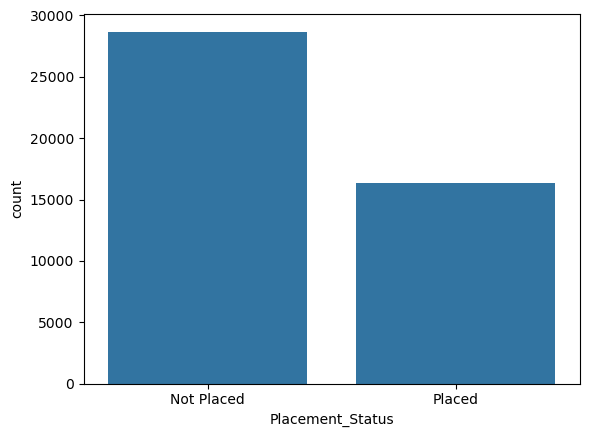

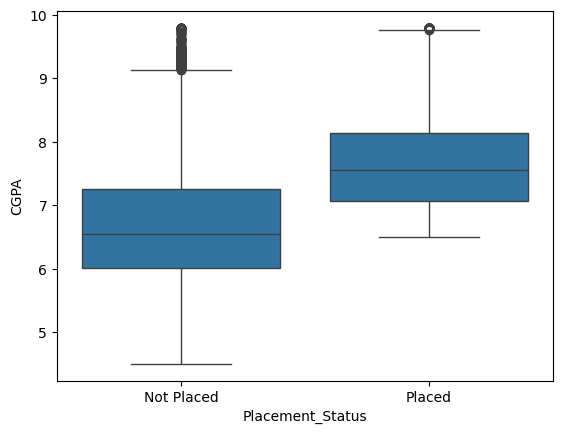

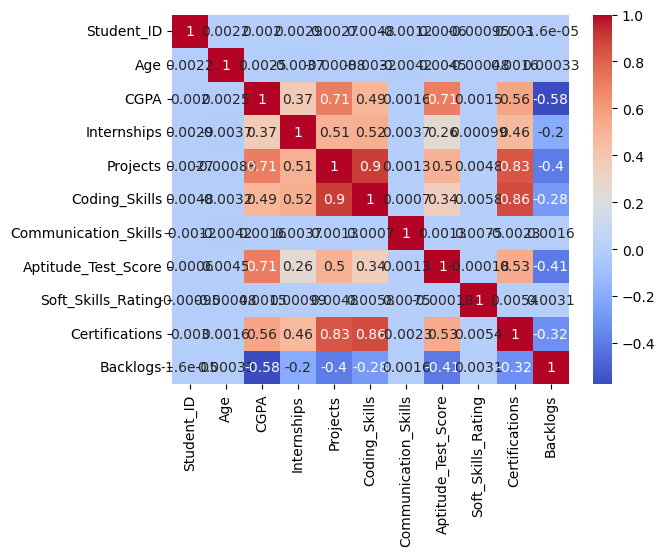

In [291]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Placement_Status", data=data)
plt.show()

sns.boxplot(x='Placement_Status', y='CGPA', data=data)
plt.show()

# Filter only numeric columns for correlation calculation

numeric_data = data.select_dtypes(include=['number'])  # Only select numeric columns
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.show()

In [292]:
#pre processing..
#split x and y

y=data["Placement_Status"]
x=data.drop(columns=["Placement_Status"])


In [293]:
#drop id column if present.

if "Student_ID" in x.columns:
    x=x.drop(columns=["Student_ID"])

In [294]:
#one hot encoding, encodes categorical columns as system understands only numerical values

cat_col=x.select_dtypes(include=['object']).columns.tolist()
print("categorical columns:",cat_col)
x_enc=pd.get_dummies(x,columns=cat_col,drop_first=True)

categorical columns: ['Gender', 'Degree', 'Branch']


In [295]:
#encode target labels(placed/notplaced)


le=LabelEncoder()
y_enc=le.fit_transform(y)
print("\nEncoded feature shape:",x_enc.shape)
print("Target classes:",list(le.classes_))


Encoded feature shape: (45000, 18)
Target classes: ['Not Placed', 'Placed']


In [296]:
x_enc.head()

,Age,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Gender_Male,Degree_B.Tech,Degree_BCA,Degree_MCA,Branch_Civil,Branch_ECE,Branch_IT,Branch_ME
0,22,6.29,0,3,4,6,51,5,1,3,False,True,False,False,False,True,False,False
1,20,6.05,1,4,6,8,59,8,2,1,False,False,True,False,False,True,False,False
2,22,7.22,1,4,6,6,58,6,2,2,True,False,False,True,False,False,False,True
3,22,7.78,2,4,6,6,90,4,2,0,True,False,False,True,False,False,False,True
4,20,7.63,1,4,6,5,79,6,2,0,False,True,False,False,False,False,False,True


In [297]:
x_train, x_test ,y_train, y_test=train_test_split(x_enc,y_enc,test_size=0.2,random_state=42)
print("train:",x_train.shape, "test:",x_test.shape)

train: (36000, 18) test: (9000, 18)


In [298]:
#feature scaling.


scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [299]:
#KNN model training..
#k=5


knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train_scaled,y_train)
y_pred=knn.predict(x_test_scaled)

In [300]:
#evaluation..

acc=accuracy_score(y_test,y_pred)
cm=confusion_matrix(y_test,y_pred)
report=classification_report(y_test,y_pred,target_names=le.classes_)

print("Accuracy:",round(acc,4))
print("\nconfusion Matrix:\n",cm)
print("\nclassification Report:\n",report)

Accuracy: 0.9094

confusion Matrix:
 [[5111  598]
 [ 217 3074]]

classification Report:
               precision    recall  f1-score   support

  Not Placed       0.96      0.90      0.93      5709
      Placed       0.84      0.93      0.88      3291

    accuracy                           0.91      9000
   macro avg       0.90      0.91      0.90      9000
weighted avg       0.91      0.91      0.91      9000



In [301]:
## cross Validation.

scores = cross_val_score(knn, x_train_scaled, y_train, cv=5)
print("KNN CV Score:", scores.mean())

KNN CV Score: 0.9099999999999999


In [302]:
## train LogisticRegression.

lr = LogisticRegression()
lr.fit(x_train_scaled, y_train)

## predictions.

y_pred_lr = lr.predict(x_test_scaled)


In [303]:
# accuracy, confusionmatrix, classification report

lr_accuracy=accuracy_score(y_test,y_pred_lr)
print("Logistic Regression Accuracy:", lr_accuracy)

print("Confusion Matrix - Logistic Regression")
print(confusion_matrix(y_test, y_pred_lr))

print("Classification Report - Logistic Regression")
print(classification_report(y_test, y_pred_lr))



Logistic Regression Accuracy: 0.8646666666666667
Confusion Matrix - Logistic Regression
[[5131  578]
 [ 640 2651]]
Classification Report - Logistic Regression
              precision    recall  f1-score   support

           0       0.89      0.90      0.89      5709
           1       0.82      0.81      0.81      3291

    accuracy                           0.86      9000
   macro avg       0.86      0.85      0.85      9000
weighted avg       0.86      0.86      0.86      9000



In [304]:
## cross Validation.

lr_cv = cross_val_score(lr, x_train_scaled, y_train, cv=5)
print("Logistic Regression CV Mean Accuracy:", lr_cv.mean())

Logistic Regression CV Mean Accuracy: 0.8678055555555556


In [305]:
## train RandomForestClassifier.

rf = RandomForestClassifier(random_state=42)
rf.fit(x_train_scaled, y_train)

## predictions.

rf_pred_y = rf.predict(x_test_scaled)

# accuracy, confusionmatrix, classification report

rf_accuracy = accuracy_score(y_test, rf_pred_y)
print("Random Forest Accuracy:", rf_accuracy)

print("Confusion Matrix - Random Forest")
print(confusion_matrix(y_test, rf_pred_y))

print("Classification Report - Random Forest")
print(classification_report(y_test, rf_pred_y))

Random Forest Accuracy: 1.0
Confusion Matrix - Random Forest
[[5709    0]
 [   0 3291]]
Classification Report - Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5709
           1       1.00      1.00      1.00      3291

    accuracy                           1.00      9000
   macro avg       1.00      1.00      1.00      9000
weighted avg       1.00      1.00      1.00      9000



In [306]:
## cross Validation.

rf_cv = cross_val_score(rf, x_train_scaled, y_train, cv=5)
print("Random Forest CV Mean Accuracy:", rf_cv.mean())

Random Forest CV Mean Accuracy: 1.0


In [307]:
## Model Comparison.

results = pd.DataFrame({
    'Model': ['knn','Logistic Regression', 'Random Forest'],
    'Accuracy': [acc,lr_accuracy, rf_accuracy]
})

results

,Model,Accuracy
0,knn,0.909444
1,Logistic Regression,0.864667
2,Random Forest,1.000000


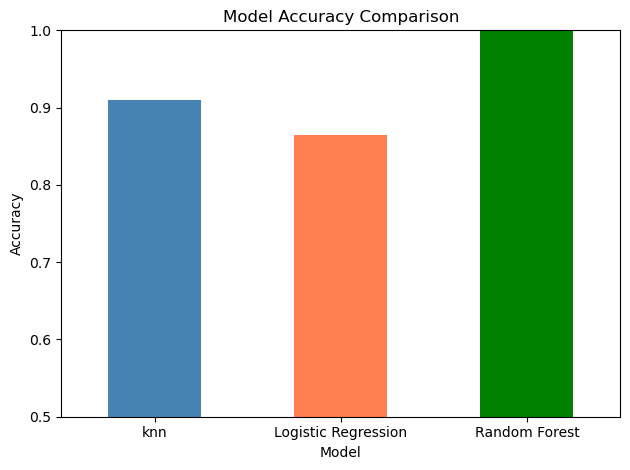

In [308]:
## Bar Chart for Model Comparision.

results.plot(x='Model', y='Accuracy', kind='bar',
             color=['steelblue', 'coral', 'green'], legend=False)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.5, 1.0)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Model Evaluation
KNN,Logistic Regression and Random Forest were evaluated using accuracy,
confusion matrix, and classification report.

Random Forest achieved higher accuracy and better recall compared to
Logistic Regression and KNN making it the best performing model for this dataset.

In [309]:
# Ensure all arrays have matching lengths by taking the minimum length
min_length = min(len(x_test), len(y_test), len(y_pred))

sample_data = x_test.copy().iloc[:min_length]  # Take only the rows that match the minimum length
sample_data["Actual"]=le.inverse_transform(y_test[:min_length])
sample_data["predicted"]=le.inverse_transform(y_pred[:min_length])
display(sample_data.head(15)[["Actual","predicted"]])

,Actual,predicted
37979,Placed,Not Placed
9911,Not Placed,Placed
43386,Not Placed,Not Placed
13822,Placed,Placed
44810,Not Placed,Not Placed
18495,Not Placed,Not Placed
25555,Placed,Placed
13316,Placed,Placed
12929,Not Placed,Placed
28374,Not Placed,Not Placed


## Conclusion

- Built a machine learning model to predict student placement.
- Performed data preprocessing and EDA.
- Compared multiple classification models.
- Achieved best accuracy using Random Forest.
- This model can help institutions identify placement readiness.